<a href="https://colab.research.google.com/github/robertzengcn/cnn_cifar10/blob/master/Audio_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: jianzezeng
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification


100%|██████████| 2.12G/2.12G [00:16<00:00, 135MB/s] 


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import Dataset,DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import time
from skimage.transform import resize

device="cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
data_df=pd.read_csv("/content/quran-recitations-for-audio-classification/files_paths.csv")
print(data_df["Class"].unique())
print(len(data_df["Class"].unique()))
data_df.head()

['Mohammed_Aluhaidan' 'Yasser_Aldossary' 'Maher_Almuaiqly'
 'Nasser_Alqutami' 'AbdulBari_Althubaity' 'Bander_Balilah'
 'Ali_Alhothaify' 'Saud_Alshuraim' 'Mohammed_Ayoub' 'AbdulRahman_Alsudais'
 'Saad_Alghamdi' 'Abdullah_Albuaijan']
12


,FilePath,Class
0,./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav,Mohammed_Aluhaidan
1,./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav,Mohammed_Aluhaidan
2,./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav,Mohammed_Aluhaidan
3,./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav,Mohammed_Aluhaidan
4,./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav,Mohammed_Aluhaidan


In [ ]:
data_df["FilePath"]="/content/quran-recitations-for-audio-classification/Dataset"+data_df["FilePath"].str[1:]
data_df.head()

,FilePath,Class
0,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
1,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
2,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
3,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan
4,/content/quran-recitations-for-audio-classific...,Mohammed_Aluhaidan


In [ ]:
data_df["FilePath"].iloc[2]

'/content/quran-recitations-for-audio-classification/Dataset/Dataset/Mohammed_Aluhaidan/lohaidan_401.wav'

Data Shape: (6687, 2)
Class Distribution Class
Saud_Alshuraim          696
Saad_Alghamdi           688
AbdulRahman_Alsudais    648
Yasser_Aldossary        576
Ali_Alhothaify          576
Bander_Balilah          576
Maher_Almuaiqly         576
Abdullah_Albuaijan      504
Mohammed_Ayoub          480
Nasser_Alqutami         456
AbdulBari_Althubaity    456
Mohammed_Aluhaidan      455
Name: count, dtype: int64


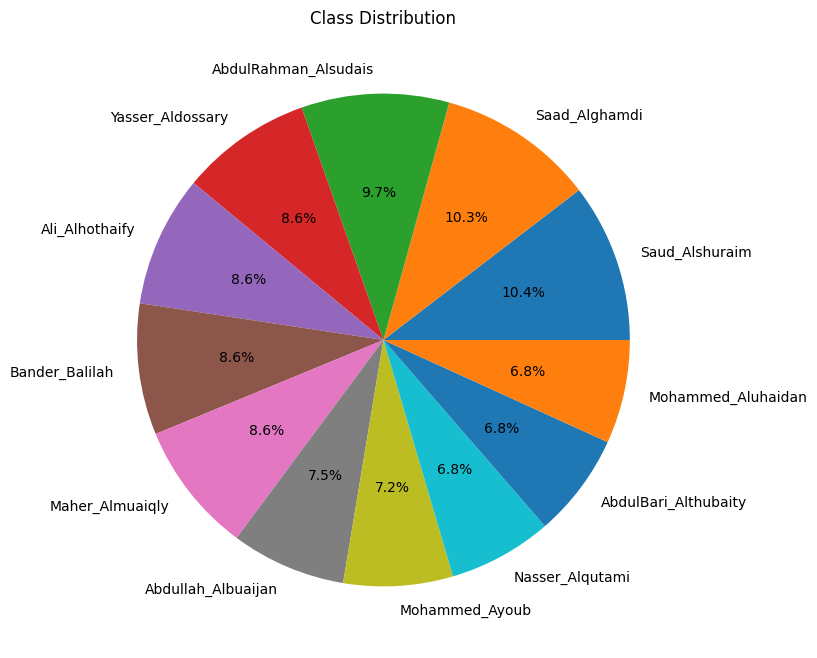

In [ ]:
print("Data Shape:",data_df.shape)
print("Class Distribution",data_df["Class"].value_counts())

plt.figure(figsize=(8,8))
plt.pie(data_df["Class"].value_counts(),labels=data_df["Class"].value_counts().index,autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()


In [ ]:
label_encoder=LabelEncoder()
data_df["Class"]=label_encoder.fit_transform(data_df["Class"])

train=data_df.sample(frac=0.7,random_state=7)
test=data_df.drop(train.index)

val=test.sample(frac=0.5,random_state=7)
test=test.drop(val.index)

print("Train Shape",train.shape)
print("Val Shape",val.shape)
print("Test Shape",test.shape)

Train Shape (4681, 2)
Val Shape (1003, 2)
Test Shape (1003, 2)


In [ ]:
data_df["Class"]

,Class
0,6
1,6
2,6
3,6
4,6
...,...
6682,2
6683,2
6684,2
6685,2


In [ ]:
import librosa

In [ ]:


class CustomAudioDataset(Dataset):
  def __init__(self,dataframe):
    self.dataframe=dataframe
    self.labels=torch.Tensor(list(dataframe["Class"])).type(torch.LongTensor).to(device)
    self.audios=[torch.Tensor(self.get_spectogram(path)).type(torch.FloatTensor) for path in dataframe["FilePath"]]
  def __len__(self):
    return self.dataframe.shape[0]
  def __getitem__(self,idx):
    img_path=self.dataframe.iloc[idx,0]
    label=torch.Tensor(self.labels[idx]).to(device)
    audio=self.audios[idx].unsqueeze(0).to(device)
    return audio,label
  def get_spectogram(self,file_path):
    sr=22050
    duration=5
    img_height=128
    img_width=256
    signal,sr=librosa.load(file_path,sr=sr,duration=duration)
    spec=librosa.feature.melspectrogram(y=signal,sr=sr,n_fft=2048,hop_length=512,n_mels=128)
    spec_db=librosa.power_to_db(spec,ref=np.max)
    spec_resized=librosa.util.fix_length(spec_db,size=(duration)//512+1)
    spec_resized=resize(spec_resized,(img_height,img_width),anti_aliasing=True)
    return spec_resized

In [ ]:
train_dataset=CustomAudioDataset(dataframe=train)
val_dataset=CustomAudioDataset(dataframe=val)
test_dataset=CustomAudioDataset(dataframe=test)

In [ ]:
LR=1e-4
BATCH_SIZE=16
EPOCHS=35


In [ ]:
train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=True)




In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d(1,16,kernel_size=3,padding=1)
    self.conv2=nn.Conv2d(16,32,kernel_size=3,padding=1)
    self.conv3=nn.Conv2d(32,64,kernel_size=3,padding=1)
    self.pooling=nn.MaxPool2d(2,2)
    self.relu=nn.ReLU()
    self.flatten=nn.Flatten()
    self.linear1=nn.Linear((64*16*32),4096)
    """
    Here's the general idea:

Convolutional Layer (kernel=3, padding=1): When you apply a convolutional layer with a 3x3 kernel and padding of 1, the spatial dimensions generally remain the same. The padding adds a border of zeros around the input, which compensates for the pixels "lost" at the edges during the convolution. So, after self.conv1, the feature maps would still be 128x256.
Pooling Layer (kernel=2, stride=2): A max pooling layer with a 2x2 kernel and a stride of 2 effectively halves the spatial dimensions. For each 2x2 block of pixels, it takes the maximum value and moves to the next block by skipping 2 pixels (because the stride is 2).
After self.pooling following self.conv1, the 128x256 feature maps would become 64x128 (128 / 2 = 64, 256 / 2 = 128).
Let's follow this through your network architecture:

Input: 128x256
self.conv1 (kernel=3, padding=1): Output size remains 128x256.
self.pooling (kernel=2, stride=2): Output size becomes 64x128.
self.conv2 (kernel=3, padding=1): Output size remains 64x128.
self.pooling (kernel=2, stride=2): Output size becomes 32x64.
self.conv3 (kernel=3, padding=1): Output size remains 32x64.
self.pooling (kernel=2, stride=2): Output size becomes 16x32.
So, after the three convolutional and pooling layers, the spatial dimensions of the feature maps are indeed 16x32. The 64 in (64*16*32) comes from the number of output channels in the last convolutional layer (self.conv3), and the 16 and 32 are the height and width of the resulting feature maps after the final pooling layer.

This is why the input size to the first linear layer is calculated as 64 * 16 * 32. It's the number of features in each flattened feature map.
    """
    self.linear2=nn.Linear(4096,1024)
    self.linear3=nn.Linear(1024,512)
    self.output=nn.Linear(512,len(data_df['Class'].unique()))

    self.dropout=nn.Dropout(0.5)

  def forward(self,x):
    x=self.conv1(x)
    x=self.pooling(x)

    x=self.conv2(x)
    x=self.pooling(x)

    x=self.conv3(x)
    x=self.pooling(x)

    x=self.relu(x)
    x=x.view(x.size(0),-1)
    """
    The selected line of code x=x.view(x.size(0),-1) is used to reshape the tensor x.

x.view(): This is a PyTorch method used for reshaping a tensor. It returns a new tensor with the same data but a different shape.
x.size(0): This gets the size of the first dimension of the tensor x. In this context, it represents the batch size. By keeping x.size(0), you ensure that the batch dimension is preserved.
-1: This is a special value that tells PyTorch to infer the size of this dimension based on the original size of the tensor and the sizes of the other specified dimensions. In this case, it flattens all the remaining dimensions into a single dimension.
So, x.view(x.size(0),-1) is taking the tensor x (which at this point has a shape like [batch_size, channels, height, width]) and reshaping it into a 2D tensor with the shape [batch_size, channels * height * width]. This is a common step before passing the output of convolutional layers to fully connected (linear) layers, as linear layers expect a flattened input.
    """
    x=self.flatten(x)
    x=self.linear1(x)
    x=self.dropout(x)

    x=self.linear2(x)
    x=self.dropout(x)
    x=self.linear3(x)
    x=self.dropout(x)
    x=self.output(x)
    return x


In [ ]:
model=Net().to(device)
print(model)

Net(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=32768, out_features=4096, bias=True)
  (linear2): Linear(in_features=4096, out_features=1024, bias=True)
  (linear3): Linear(in_features=1024, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=12, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
from torchsummary import summary
summary(model,(1,128,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
         MaxPool2d-2          [-1, 16, 64, 128]               0
            Conv2d-3          [-1, 32, 64, 128]           4,640
         MaxPool2d-4           [-1, 32, 32, 64]               0
            Conv2d-5           [-1, 64, 32, 64]          18,496
         MaxPool2d-6           [-1, 64, 16, 32]               0
              ReLU-7           [-1, 64, 16, 32]               0
           Flatten-8                [-1, 32768]               0
            Linear-9                 [-1, 4096]     134,221,824
          Dropout-10                 [-1, 4096]               0
           Linear-11                 [-1, 1024]       4,195,328
          Dropout-12                 [-1, 1024]               0
           Linear-13                  [-1, 512]         524,800
          Dropout-14                  [

In [ ]:
"""
The selected line optimizer = Adam(model.parameters(), lr=LR) is setting up the optimization algorithm for training your neural network model.

Here's a breakdown:

optimizer = ...: This assigns the created optimizer object to the variable optimizer. You'll use this object to perform the weight updates during the training process.
Adam(...): This is calling the Adam optimizer class from PyTorch's optim module. Adam is a popular optimization algorithm that adapts the learning rate for each parameter individually.
model.parameters(): This method of your model object returns an iterator over all the parameters (weights and biases) of the neural network. The optimizer needs to know which parameters it should update during training.
lr=LR: This sets the learning rate for the optimizer. The learning rate determines the step size at which the optimizer updates the model's parameters. LR is a variable that you defined earlier (likely in cell ZsZN0Kx6rL2F) with a value of 1e-4.
In essence, this line is telling PyTorch to use the Adam optimizer with a learning rate of 0.0001 to update the weights and biases of your model during training.
"""
criteration=nn.CrossEntropyLoss()
optimizer=Adam(model.parameters(),lr=LR)

In [ ]:
import time
total_loss_train_plot=[]
total_loss_validation_plot=[]
total_acc_train_plot=[]
total_acc_validation_plot=[]
start_time=time.time()

for epoch in range(EPOCHS):
  total_acc_train=0
  total_loss_train=0
  total_loss_val=0.
  total_acc_val=0
  for input, labels in train_loader:
    outputs=model(input)
    train_loss=criteration(outputs,labels)
    total_loss_train+=train_loss.item()
    train_loss.backward()

    train_acc=(torch.argmax(outputs,axis=1)==labels).sum().item()
    total_acc_train+=train_acc

    optimizer.step()
    optimizer.zero_grad()
  with torch.no_grad():
    for input,labels in val_loader:
      outputs=model(input)
      val_loss=criteration(outputs,labels)
      total_loss_val+=val_loss.item()
      val_acc=(torch.argmax(outputs,axis=1)==labels).sum().item()
      total_acc_val+=val_acc
  total_loss_train_plot.append(round(total_loss_train/1000,4))
  total_loss_validation_plot.append(round(total_loss_val/1000,4))
  total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__()*100,4))
  total_acc_validation_plot.append(round(total_acc_val/val_dataset.__len__()*100,4))

  print(f"Epoch:{epoch+1}/{EPOCHS},Train Loss:{round(total_loss_train/100,4)},Train Accuracy:{round(total_acc_train/train_dataset.__len__()*100,4)} Validation Loss:{round(total_loss_val/1000,4)}, Validation Accuracy: {round(total_acc_val/val_dataset.__len__()*100,4)}")
  print("="*30)
print("Training Time is:",round(time.time()-start_time,4),"Seconds")


Epoch:1/35,Train Loss:1.2387,Train Accuracy:86.4772 Validation Loss:0.0851, Validation Accuracy: 70.7876
Epoch:2/35,Train Loss:1.1976,Train Accuracy:86.755 Validation Loss:0.0783, Validation Accuracy: 71.1864
Epoch:3/35,Train Loss:1.1858,Train Accuracy:86.99 Validation Loss:0.0695, Validation Accuracy: 72.4826
Epoch:4/35,Train Loss:1.0833,Train Accuracy:87.9513 Validation Loss:0.078, Validation Accuracy: 70.987
Epoch:5/35,Train Loss:1.0093,Train Accuracy:88.6563 Validation Loss:0.0799, Validation Accuracy: 69.7906
Epoch:6/35,Train Loss:1.0485,Train Accuracy:88.2504 Validation Loss:0.0835, Validation Accuracy: 71.984
Epoch:7/35,Train Loss:1.1013,Train Accuracy:87.8445 Validation Loss:0.0815, Validation Accuracy: 70.7876
Epoch:8/35,Train Loss:0.9783,Train Accuracy:89.0622 Validation Loss:0.0992, Validation Accuracy: 69.3918
Epoch:9/35,Train Loss:1.0083,Train Accuracy:88.7204 Validation Loss:0.0839, Validation Accuracy: 71.0867
Epoch:10/35,Train Loss:0.8986,Train Accuracy:90.3012 Validati

In [ ]:
with torch.no_grad():
  torch_loss_test=0
  total_acc_test=0
  for input, labels in test_loader:
    prediction=model(input)
    acc=(torch.argmax(prediction,axis=1)==labels).sum().item()
    total_acc_test+=acc
print(f"Total Accuracy Score is:",{round(total_acc_test/test_dataset.__len__()*100,4)})

Total Accuracy Score is: {73.1805}


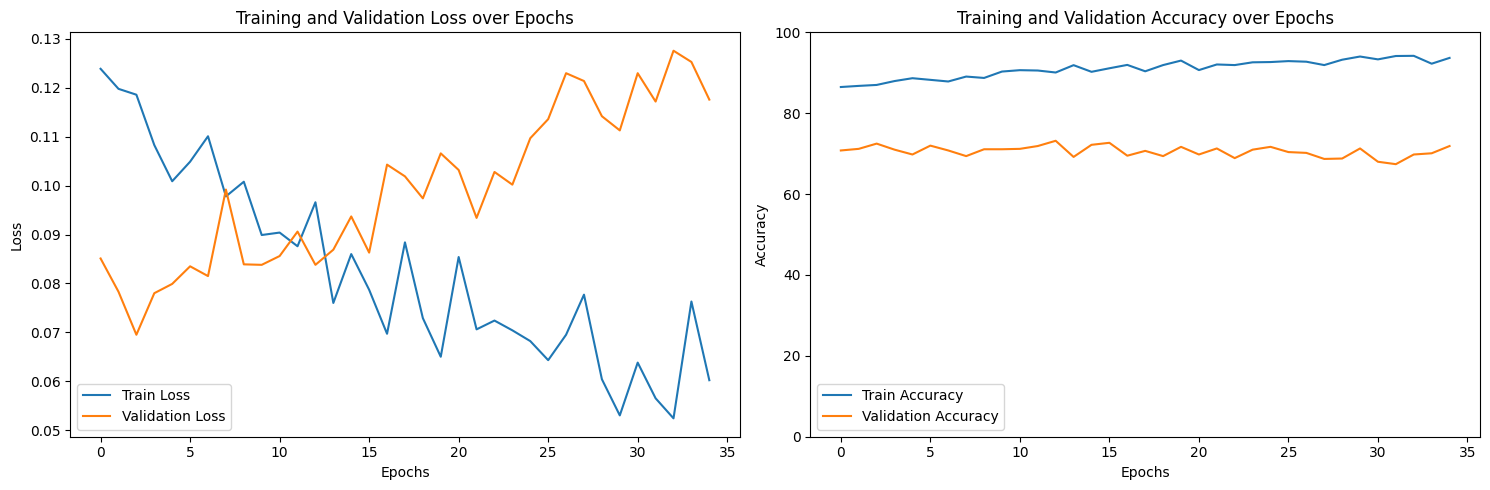

In [ ]:
fig, axs=plt.subplots(nrows=1,ncols=2,figsize=(15,5))
axs[0].plot(total_loss_train_plot,label="Train Loss")
axs[0].plot(total_loss_validation_plot,label="Validation Loss")
axs[0].set_title("Training and Validation Loss over Epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
#axs[0].set_ylim(0,2)
axs[0].legend()

axs[1].plot(total_acc_train_plot,label="Train Accuracy")
axs[1].plot(total_acc_validation_plot,label="Validation Accuracy")
axs[1].set_title("Training and Validation Accuracy over Epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].set_ylim(0,100)
axs[1].legend()

plt.tight_layout()
plt.show()